# From Text to Data
### An Introduction to NLP for Empirical Research

**DAISY International Summer School — Data Analytics for Innovation and Sustainability**  
*Taranto, September 2026*

---

Natural Language Processing in Python: Four methods for classification of innovation and sustainability data

## Does a patent describe a **green technology**?

We will answer this question four times, with four families of methods belonging to Natural Language Processing, a subset of AI. 

Main objectives: 
1. Learn how those methods **work**
2. Learn how to **choose** between them for your own data
3. Learn how to **justify** your choice


Every method we see today is the same pipeline:

```
    TEXT  ------>  NUMBERS  ------>  MODEL  ------>  LABEL
```

Only the middle arrow changes:

| Method | How text becomes numbers |
|---|---|
| **Dictionary methods** | define and detect keywords |
| **TF-IDF** | count words, downweight the common ones |
| **Sentence embeddings** | map meaning into a vector space |
| **LLM** | the model outputs the label directly |


## Text as data in innovation and sustainability research

Text is everywhere, but it almost never arrives ready to use:

- **Patent titles, abstracts and claims** &rarr; technological content, novelty, green vs non-green
- **Sustainability and ESG reports** &rarr; firm disclosure, greenwashing detection
- **Grant proposals and scientific abstracts** &rarr; novelty, interdisciplinarity, topic dynamics
- **Job postings** &rarr; skill demand, green jobs
- **Policy and regulatory documents** &rarr; stringency, agenda-setting

&rarr; In every case, the workflow is the same: **turn unstructured text into a structured variable** that can enter a regression, a classifier, or a network.

### Our task today

We use real patent data from **PATSTAT** to classify inventions as *green* / *non-green* using titles and abstracts.

We will also rely on a binary `green` label derived from CPC (Cooperative Patent Classification) codes to validate and test our text classification.

> **Methodological warning.** Our label is not a ground truth, but it is the output of a *classification rule* built by the EPO (European Patent Office), with its own inclusion criteria and its own errors. Every accuracy number we compute today is accuracy *relative to that rule*. 

## 0. Setup

`pandas`, `numpy`, `scikit-learn` and `matplotlib` come pre-installed on Colab. We add `sentence-transformers` for advanced natural language processing.

In [ ]:
# --- Install sentence-transformers --- 

!pip install -q sentence-transformers

In [ ]:
# --- Load packages ---
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_colwidth', 200)

## 1. The data

The dataset was extracted from PATSTAT in advance and is hosted on GitHub.

In [ ]:
DATA_URL = 'https://raw.githubusercontent.com/martina-iori/DAISY_NLP_in_Python/main/data/patstat_green_sample.csv'

df = pd.read_csv(DATA_URL)
print(df.shape)
df.head(3)

In [ ]:
# --- Normalise the label and build the text field ---

# 'green' may come as 0/1, True/False, or 'yes'/'no' -> make it a clean 0/1 integer
if df['green'].dtype == object:
    df['green'] = (df['green'].astype(str).str.strip().str.lower()
                   .isin(['1', 'yes', 'y', 'true', 't']).astype(int))
else:
    df['green'] = df['green'].astype(int)

# Title and abstract carry complementary signal -> use both
df['title'] = df['title'].fillna('')
df['abstract'] = df['abstract'].fillna('')
df['text'] = (df['title'] + '. ' + df['abstract']).str.strip()

# Drop rows with no usable text
before = len(df)
df = df[df['text'].str.split().apply(len) >= 5].copy()
print(f'Dropped {before - len(df)} rows with (almost) empty text')

df[['appln_id', 'title', 'earliest_filing_year', 'green']].head()

### Deduplication: Remove near-identical abstracts

Patent families produce near-identical abstracts across jurisdictions.
We remove exact duplicates of the text field. In a real project, you would go further (fuzzy matching or deduplication on family ID).

In [ ]:
before = len(df)
df = df.drop_duplicates(subset='text').reset_index(drop=True)
print(f'Removed {before - len(df)} exact duplicate texts. {len(df)} remain')

### Look at the data before modelling it

Class balance and text length determine which metrics are meaningful and which models are feasible.

In [ ]:
print('Share green:', df['green'].mean().round(3))
print()
print(df['green'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('earliest_filing_year')['green'].mean().plot(ax=axes[0], marker='o', c='darkgreen')
axes[0].set_ylabel('Share green')
axes[0].set_xlabel('Earliest application year')
axes[0].set_title('Green share over time')

df['n_words'] = df['text'].str.split().apply(len)
df['n_words'].clip(upper=df['n_words'].quantile(0.99)).hist(bins=40, ax=axes[1])
axes[1].set_xlabel('Words per document (title + abstract)')
axes[1].set_title('Document length')

plt.tight_layout()
plt.show()

**Read at least two documents, one per class.** This step catches encoding problems, truncated abstracts, and mislabelled records.

In [ ]:
for lab in [1, 0]:
    ex = df[df['green'] == lab].sample(1, random_state=RANDOM_STATE).iloc[0]
    print(f"--- green={lab} | appln_id={ex['appln_id']} ---")
    print(ex['text'][:600], '\n')

## 2. Train / validation / test

The AI basics: data must be divided into three sets, each of which has a specific and crucial role in creating and testing good models.

This is the most important methodological point of the session, and it holds **for every method we use today**, LLMs included.

| Set | Purpose | How often may you look at it? |
|---|---|---|
| **Train** | the model learns its parameters here | continuously |
| **Validation** | you compare models, tune settings, iterate on prompts | as often as you like |
| **Test** | the number you put in the paper | **only once** |

The train set is only used in supervised models, i.e., AI models trained using labeled data to map inputs to known outputs.

### Why three and not two

Every time you make a choice by looking at a set — which features, which regularisation, which prompt wording — you fit *yourself* to that set. After iterations, performance on it is optimistic, even though the model never trained on it. The test set exists to stay clean through all of that.

### Mistakes that invalidate the whole exercise

- Choosing hyperparameters by checking test performance
- Running the test evaluation several times and reporting the best
- Leaving duplicates or family members across the split (if the text is the same, you will overestimate the model performance)
- Building a keyword list, or writing an LLM prompt, while reading test examples &rarr; A prompt you refined by looking at test documents is overfitted to the test set just as a regression tuned on it.

In [ ]:
# --- Train set: 60% of the dataset; Validation and test sets: 20% each of the dataset ---

train_df, temp_df = train_test_split(
    df, test_size=0.4, stratify=df['green'], random_state=RANDOM_STATE)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['green'], random_state=RANDOM_STATE)

for name, d in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f'{name:11s} n={len(d):6d}   share green={d["green"].mean():.3f}')

`stratify` keeps the class proportions identical across the three sets. Without it, an imbalanced dataset can produce a validation set with very few positives, and your metrics become extremely noisy.

### Measuring performance

Predictions can be divided into:
- TP = True Positive &rarr; Patents predicted as green that are green patents
- TN = True Negative &rarr; Patents predicted as non-green that are non-green patents
- FP = False Positive &rarr; Patents predicted as green that are non-green patents
- FN = False Negative &rarr; Patents predicted as non-green that are green patents


We define the evaluation function now, so that every method from here on is judged identically.

**Main evaluation metrics**:

1. **Accuracy** — how often the model is correct overall?

$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$

**Why accuracy alone will mislead you.** With imbalanced classes, a model that always predicts the majority class already scores well while being useless. So we compute that *trivial benchmark* first: it is the bar every real model must clear.

2. **Precision** — of those predicted green, how many really are? (cost of false positives)

$Precision = \frac{TP}{TP + FP}$

3. **Recall** — of the truly green, how many did we catch? (cost of false negatives)

$Recall  = \frac{TP}{TP + FN}$

4. **F1** — harmonic mean of the precision and recall

$F1 = 2\cdot\frac{Precision \cdot Recall}{Precision + Recall}$

Which one matters is a substantive question. If you are measuring a country's *stock* of green patents, recall failures shrink your dependent variable systematically, and precision failures inflate it. Usually, a good model has an F1 > 0.7.

In [ ]:
# --- Define evaluation functions ---

def report(y_true, y_pred, name, store=None):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0)
    print(f'{name}')
    print(f'  accuracy {acc:.3f} | precision {p:.3f} | recall {r:.3f} | F1 {f1:.3f}')
    row = {'model': name, 'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}
    if store is not None:
        store.append(row)
    return row

results = []

# The bar to beat: always predict the majority class
majority = int(train_df['green'].mean() > 0.5)
report(val_df['green'], np.full(len(val_df), majority),
       f'Always predict {majority} (trivial benchmark)', results)

## 3. Dictionary methods (keyword search): the simplest thing that could work

Before any statistical model, there is an approach that requires no training data at all: write down the words that identify the concept, and detect them in texts.

Expert-curated keyword lists are really common in the literature. Those methods are transparent, free, rapid, and fully reproducible.

In our pipeline diagram, the middle step is as simple as it gets:

```
    TEXT  ------>  does it match any keyword?  ------>  LABEL
```

NB: In this case, the training set is not used.

In [ ]:
# --- Dictionary classification ---

# An expert-curated list of green-technology terms.
# In a real project this would come from domain literature and iteration on validation.
GREEN_TERMS = [
    'photovoltaic', 'solar cell', 'solar panel', 'wind turbine', 'wind power',
    'renewable energy', 'geothermal', 'biomass', 'biofuel', 'hydrogen fuel',
    'fuel cell', 'energy storage', 'energy efficiency', 'heat recovery',
    'carbon capture', 'carbon dioxide capture', 'greenhouse gas', 'emission reduction',
    'electric vehicle', 'hybrid vehicle', 'battery charging', 'smart grid',
    'waste heat', 'recycling', 'waste treatment', 'water treatment',
]

# Word-boundary regex so that 'solar' does not match 'solarium'
pattern = re.compile(r'\b(' + '|'.join(re.escape(t) for t in GREEN_TERMS) + r')\b',
                     flags=re.IGNORECASE)

def dictionary_predict(text):
    return int(bool(pattern.search(text)))

# all performance metrics must be computed on the validation set!
pred_dict = val_df['text'].apply(dictionary_predict).values
report(val_df['green'], pred_dict, 'Dictionary (keyword match)', results)

### Read the confusion matrix

Dictionary methods typically show a characteristic signature: good precision, poor recall. 

When a keyword matches it is usually right, but the list cannot possibly contain every way an applicant might describe a technology. Moreover, patent attorneys have professional incentives to phrase claims in non-obvious language.

In [ ]:
# --- Confusion Matrix ---

cm_dict = confusion_matrix(val_df['green'], pred_dict)
ConfusionMatrixDisplay(cm_dict, display_labels=['non-green', 'green']).plot(cmap='Oranges')
plt.title('Dictionary — validation')
plt.show()

# Which green patents does the dictionary miss entirely?
missed = val_df[(val_df['green'] == 1) & (pred_dict == 0)]
print(f'Green patents missed by the dictionary: {len(missed)}\n')
print('Two examples of missed patents: \n')
for _, r in missed.sample(min(2, len(missed)), random_state=RANDOM_STATE).iterrows():
    print(r['text'][:350], '\n')

**Discussion.** Look at what the dictionary missed. Now consider what happens if you use a keyword-based green measure as a **dependent variable** in a regression.

The errors are not random noise. A dictionary systematically misses the technologies whose vocabulary it does not contain — which tends to mean newer fields, emerging terminology, and firms that patent less. Measurement error correlated with the very things you are trying to explain is a confounding factor.

**Exercise.** Add two or three terms to `GREEN_TERMS` and re-run. How much does recall move? Notice that you are tuning on the **validation** set, which is exactly where tuning belongs. Doing this against the test set would destroy the credibility of your final metrics.

## 4. Preprocessing and TF-IDF

While the dictionary forced us to write the vocabulary by hand, TF-IDF (Term Frequency - Inverse Document Frequency) learns it from the (train) data. Every word becomes a feature, and the model decides which ones matter based on the frequency of the term in the corpus of documents.

**Step 1 - the document-term matrix.** Each document becomes a row, each word a column, each cell a count. Word order is discarded entirely (hence *bag of words*).

**Step 2 - the IDF weighting.** A word appearing in every document carries no discriminating information. TF-IDF multiplies each count by the *inverse document frequency*, so rare-but-present words get a high weight and ubiquitous ones get crushed towards zero.

$$\text{tfidf}(t, d) = \underbrace{\text{count}(t, d)}_{\text{term frequency}} \times \underbrace{\log \frac{N}{n_t}}_{\text{inverse doc. frequency}}$$

where $d$ is a document, $t$ a term, $N$ is the number of documents and $n_t$ the number containing term $t$.

**Step 3 - classification.** The vectorial representation of documents based on TF-IDF informs the document similarity, which is then used to train a classifier based on the training set.

Let's start with an example.

In [ ]:
toy = ['solar panel for energy production',
       'wind turbine for energy production',
       'method for data processing']

toy_vec = TfidfVectorizer()
toy_matrix = toy_vec.fit_transform(toy)

pd.DataFrame(toy_matrix.toarray().round(2),
             columns=toy_vec.get_feature_names_out(),
             index=['doc 1', 'doc 2', 'doc 3'])

`for` appears in all three documents and gets a **low** weight everywhere. `solar` appears once and gets a high weight in that document only. 

Note also what the matrix cannot see: `solar panel` and `panel solar` would be identical rows. This is the fundamental limitation we address in Section 5.

Now, let's apply it to the real data.

### First: Preprocessing

`TfidfVectorizer` takes arguments. Each one is a research decision that changes what your variable measures. They belong in your appendix alongside your sample construction.

In patent texts, some words — *comprising*, *said*, *apparatus*, *means for*, *plurality*, *thereof* — appear in nearly every document and carry no technological content.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

raw = CountVectorizer()
M = raw.fit_transform(train_df['text'])
freq = pd.Series(np.asarray(M.sum(axis=0)).ravel(),
                 index=raw.get_feature_names_out()).sort_values(ascending=False)

print('Vocabulary size, no filtering:', len(freq))
print('\n20 most frequent tokens:')
print(freq.head(20).to_string())

Now compare what different settings do to the size of the feature space.

In [ ]:
configs = {
    'raw counts':                 dict(),
    '+ English stopwords':        dict(stop_words='english'),
    '+ min threshold=3':          dict(stop_words='english', min_df=3), 
    '+ bigrams':                  dict(stop_words='english', min_df=3, ngram_range=(1, 2))
}

for name, kw in configs.items():
    v = CountVectorizer(**kw).fit(train_df['text'])
    print(f'{name:24s} vocabulary = {len(v.get_feature_names_out()):>7,}')

The generic English stopword list was built for ordinary prose, so it removes some patent common words and misses most of it. 

Domain corpora need domain-specific preprocessing, which in practice means extending the list yourself after reading the frequency table above.

`min_df` does most of the remaining work. Most of a corpus vocabulary consists of terms appearing once or twice — typos, chemical formulae, proper nouns — which cannot support estimation and mainly add noise and memory cost.

> Preprocessing is covered in much more depth in notebook 2 of the `text_algorithms_econ` repository.


In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# A domain-aware stopword list: generic English plus patent common_words
PATENT_STOPWORDS = list(ENGLISH_STOP_WORDS) + [
    'comprising', 'comprises', 'said', 'apparatus', 'means', 'plurality',
    'thereof', 'configured', 'device', 'method', 'invention', 'embodiment',
    'present', 'claim', 'accordance', 'preferably',
]
print(f'\nDomain stopword list: {len(PATENT_STOPWORDS)} terms')

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=20000,      # most frequent terms
    ngram_range=(1, 2),      # unigrams and bigrams
    stop_words='english',
    min_df=3                 # ignore terms in fewer than 3 documents
)

X_train = vectorizer.fit_transform(train_df['text'])   # fit ONLY on training data
X_val = vectorizer.transform(val_df['text'])           # validation is only transformed

print('Document-term matrix:', X_train.shape)
print('Density: {:.4f}%'.format(100 * X_train.nnz / (X_train.shape[0] * X_train.shape[1])))

### Second: Classification
> **Why `fit_transform` on train but `transform` on validation?** The vocabulary and the IDF weights are *learned parameters*. Fitting them on the full dataset would let information from the validation set leak into the representation.

In [ ]:
# --- Classification based on a Logistic Regression ---

clf_tfidf = LogisticRegression(max_iter=2000, class_weight='balanced',
                               random_state=RANDOM_STATE)
clf_tfidf.fit(X_train, train_df['green'])

pred_tfidf = clf_tfidf.predict(X_val)

### Third: Performance on the validation set

We use the same validation set used for the dictionary.

In [ ]:
report(val_df['green'], pred_tfidf, 'TF-IDF + LogReg', results)

In [ ]:
cm = confusion_matrix(val_df['green'], pred_tfidf)
ConfusionMatrixDisplay(cm, display_labels=['non-green', 'green']).plot(cmap='Blues')
plt.title('TF-IDF + LogReg — validation')
plt.show()

### Interpretability

Because the model is linear over words, we can read its coefficients directly. This is a real advantage over both embeddings and LLMs. It is a diagnostic: if the top terms look like artefacts rather than technology, something is wrong with your label or your sample.

In [ ]:
feat = np.array(vectorizer.get_feature_names_out())
coefs = clf_tfidf.coef_[0]
order = np.argsort(coefs)

print('Strongest GREEN indicators:')
for t, c in zip(feat[order[-15:]][::-1], coefs[order[-15:]][::-1]):
    print(f'  {c:+.2f}  {t}')

print('\nStrongest NON-GREEN indicators:')
for t, c in zip(feat[order[:15]], coefs[order[:15]]):
    print(f'  {c:+.2f}  {t}')

**Exercise.** Change one setting and re-run the cells above:

- `ngram_range=(1, 1)` — does dropping bigrams hurt?
- `max_features=2000` — how much of the vocabulary do you actually need?
- remove `class_weight='balanced'` — watch recall on the green class collapse

Compare what you get with the dictionary result. TF-IDF usually wins on recall, because it is not limited to terms a human thought of in advance.

## 5. Sentence embeddings

TF-IDF matches strings, but it misses synonyms. For insteance, *photovoltaic module* and *solar cell array* share no tokens, so to TF-IDF they are as unrelated as either is to *hydraulic pump*. Patent language is full of this kind of variation, as applicants have incentives to phrase claims in non-obvious ways.

### What an embedding is

A pretrained neural model maps each document to a fixed-length vector (384 numbers for the model below), positioned so that texts with similar meaning land close together. Closeness is measured by cosine similarity, the cosine of the angle between two vectors: 1 means same direction, 0 means unrelated.

$$\cos(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \, \|\mathbf{b}\|},$$
where *a* and *b* are two documents (e.g., patent abstracts).

We are not training a neural network, but we download a model someone else trained. We then use it as a fixed feature extractor to transfor our documents into vectors and run a logistic regression to identify green patents based on text similarity.

BERT (Bidirectional Encoder Representations for Transformers) produces a vector *per token*, not per document, and averaging those tokens gives mediocre document vectors. **Sentence-BERT (SBERT)** is BERT further trained on sentence-pair tasks so that the document-level output is directly comparable using cosine similarity. That is what `sentence-transformers` gives us, and it is why we can drop the output straight into a logistic regression.

Several pre-trained models exists. Among others, `all-MiniLM-L6-v2` for compact general-purpose sentence transformer, SciBERT for scientific text, FinBERT for financial text, and PatentSBERTa for patents.

In [ ]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer('all-MiniLM-L6-v2')
print('Embedding dimension:', embedder.get_sentence_embedding_dimension())

### Demo: meaning without shared words

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

probe = ['a photovoltaic module converting sunlight into electricity',
         'a solar cell array for electric power generation',
         'a hydraulic pump for industrial machinery']

emb_probe = embedder.encode(probe)
sim_emb = cosine_similarity(emb_probe)

tfidf_probe = TfidfVectorizer().fit_transform(probe)
sim_tfidf = cosine_similarity(tfidf_probe)

labels = ['photovoltaic', 'solar cell', 'hydraulic']
print('Cosine similarity — TF-IDF:')
print(pd.DataFrame(sim_tfidf.round(2), index=labels, columns=labels))
print('\nCosine similarity — embeddings:')
print(pd.DataFrame(sim_emb.round(2), index=labels, columns=labels))

The first two sentences describe the same technology in different words. TF-IDF sees almost nothing in common. The embedding model places them closer.

### Encode the corpus

This is the slowest cell of the notebook. Switching the runtime to GPU (*Runtime → Change runtime type → T4*) makes it much faster.

### Why *contextual* embeddings matter: the same word, different meanings

TF-IDF assigns one column to a word, whatever it means. Sequence models let the surrounding words change the representation. Patent text is a good place to see this, because the same term recurs across unrelated technological fields.

In [ ]:
# --- Example: cell ---

cases = ['a solar cell converting light into electrical current',
         'a battery cell with improved electrolyte composition',
         'a cell phone with a touch sensitive display',
         'a biological cell culture incubator']

sim = cosine_similarity(embedder.encode(cases))
labels = ['solar cell', 'battery cell', 'cell phone', 'cell culture']
print(pd.DataFrame(sim.round(2), index=labels, columns=labels))

All four contain the token *cell*. To a bag-of-words model like TF-IDF that shared token is evidence of similarity. The embedding model separates them by context, which is the behaviour we desire when we classify patents based on what the technology does.

In [ ]:
# --- Embeddings of patents in the train and validation sets ---

E_train = embedder.encode(train_df['text'].tolist(), batch_size=64,
                          show_progress_bar=True)
E_val = embedder.encode(val_df['text'].tolist(), batch_size=64,
                        show_progress_bar=True)

print('Embedding matrix:', E_train.shape)

### See the space

384 dimensions are not visualisable, but PCA can project them onto two. This is a compression, so overlap on screen does not mean overlap in the full space (it is only a qualitative check).

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
P = pca.fit_transform(E_train)

plt.figure(figsize=(7, 6))
for lab, colour, name in [(0, 'lightsteelblue', 'non-green'), (1, 'seagreen', 'green')]:
    m = train_df['green'].values == lab
    plt.scatter(P[m, 0], P[m, 1], s=6, alpha=0.7, c=colour, label=name)
plt.legend()
plt.title('Patent abstracts in embedding space (PCA to 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} of variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} of variance)')
plt.show()

In [ ]:
# --- Classification based on a Logistic Regression ---

clf_emb = LogisticRegression(max_iter=2000, class_weight='balanced',
                             random_state=RANDOM_STATE)
clf_emb.fit(E_train, train_df['green'])

pred_emb = clf_emb.predict(E_val)
report(val_df['green'], pred_emb, 'Embeddings + LogReg', results)

### Error analysis: look at what it gets wrong

Aggregate metrics tell you *how much* the model fails, but only reading errors you learn *why*.

In [ ]:
val_check = val_df.copy()
val_check['pred'] = pred_emb
errors = val_check[val_check['pred'] != val_check['green']]
print(f'{len(errors)} errors out of {len(val_check)}\n')

for _, r in errors.sample(min(3, len(errors)), random_state=RANDOM_STATE).iterrows():
    print(f"true={r['green']}  pred={r['pred']}  appln_id={r['appln_id']}")
    print(r['text'][:400], '\n')

In [ ]:
# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, preds, name in zip(axes,
                           [pred_tfidf, pred_emb],
                           ['TF-IDF + LogReg', 'Embeddings + LogReg']):
    cm = confusion_matrix(val_df['green'], preds)
    ConfusionMatrixDisplay(cm, display_labels=['non-green', 'green']).plot(
        ax=ax, cmap='Greens', colorbar=False)
    ax.set_title(name)

plt.suptitle('Confusion Matrix')
plt.tight_layout()
plt.show()

**Discussion.** Read those errors together. Ask each time: *is this the model being wrong, or the CPC-based label being wrong?* Dual-use technologies — a battery that is green in a storage application and not in a consumer device — are where both the rule and the classifier struggle. 

### Warnings

Suppose the classifier works well and you now put `predicted_green` on the left- or right-hand side of a regression. Two problems follow.

**1. Generated regressors.** Your text-based variable is an estimate and not an observation. Standard errors in the downstream regression that ignore the uncertainty of the upstream classification are too small. Ash and Hansen (2023) discuss this explicitly. Possible solutions: bootstrapping the whole pipeline or a joint model of text and covariates.

**2. The problem of style.** It is tempting to assume that a more sophisticated model has less measurement error, but the direction can reverse: Ash and Hansen point out that BERT-style models are in some ways more exposed to this problem than dictionaries, because they exploit subtle stylistic cues - even punctuation - that a keyword list cannot see. If drafting style correlates with firm size, jurisdiction, or law firm, the classifier may be partly measuring who wrote the patent rather than what it covers.

## 6. LLM zero-shot: A demo

### How it differs

An LLM is trained to predict the next token over enormous amounts of text. That objective turns out to produce enough general knowledge that you can simply *ask* for a classification in natural language, with no labelled training data at all. In our pipeline diagram, the LLM collapses the middle steps: text goes in, a label comes out.

This is useful for pilot studies, for labelling a few hundred documents to bootstrap a supervised model, or for tasks too nuanced to express as features.

### The trade-offs

| | Dictionary | TF-IDF | Embeddings | LLM API |
|---|---|---|---|---|
| Labelled data needed | no | yes | yes | no |
| Marginal cost per document | ~0 | ~0 | ~0 after download | paid per call |
| Cost at 1M documents | negligible | negligible | hours of compute | often prohibitive |
| Reproducible in 3 years | perfectly | yes | yes, if you pin the model | model versions get deprecated |
| Interpretability | total | high | low | low, and explanations are not mechanisms |
| Infrastructure | laptop | laptop | laptop / free GPU | internet, API key, budget |
| Typical weakness | recall | paraphrase | opacity | cost, drift |

The reproducibility is crucial. If your results depend on a hosted model version that is retired next year, your paper is not replicable. Record the exact model identifier, the prompt, the date, and keep the raw outputs.

### Validation is still crucial

Zero-shot removes the training data, but it does **not** remove the need for validation. An LLM's label is a prediction, and it goes through the same validation set and the same metrics as the other models. 

This is the code that produced the predictions. It is only shown as the workshop environment has no API key and no `google-genai` installed.

The full version is `precompute_llm_gemini.py` in the repository.

```python
import os
import re

from google import genai
from google.genai import types

PROMPT = """You are classifying patent documents.

Decide whether the patent below describes a GREEN technology, meaning a technology
whose purpose is climate change mitigation or adaptation: renewable energy generation,
energy storage for decarbonisation, energy efficiency, carbon capture, waste recycling
and circular material recovery, clean transport, or emission abatement.

Answer with exactly one word: green or nongreen.

Title: {title}
Abstract: {abstract}"""

client = genai.Client(api_key=os.environ['GEMINI_API_KEY'])

# temperature=0: without it the same request can return different answers on different runs and these numbers would not be reproducible.
CONFIG = types.GenerateContentConfig(
    temperature=0,
    max_output_tokens=200,
    thinking_config=types.ThinkingConfig(thinking_budget=0),
)


def parse(answer):
    """Map the model's text to 1 (green), 0 (nongreen), or None."""
    if not answer:
        return None
    a = re.sub(r'[^a-z\- ]', '', answer.strip().lower())
    if 'nongreen' in a or 'non-green' in a or 'non green' in a:
        return 0
    if 'green' in a:
        return 1
    return None   # unparseable


def llm_classify(title, abstract, model='gemini-3.1-flash-lite'):
    resp = client.models.generate_content(
        model=model,
        contents=PROMPT.format(title=title, abstract=abstract[:1500]),
        config=CONFIG,
    )
    return parse(resp.text)
```

### The LLM predictions

The whole validation set was scored ahead of the class and the answers committed to the repository, together with `llm_run_metadata.json` recording the model version, the date and the exact prompt for reproducibility purposes.

In [ ]:
LLM_URL = DATA_URL.rsplit('/', 1)[0] + '/llm_val_predictions.csv'

llm = pd.read_csv(LLM_URL)
val_llm = val_df.merge(llm, on='appln_id', how='inner')

# The model occasionally answers something unparseable
n_bad = val_llm['llm_pred'].isna().sum()
print(f'Scored: {len(val_llm)} | unparseable answers: {n_bad}')

val_llm = val_llm.dropna(subset=['llm_pred'])
report(val_llm['green'], val_llm['llm_pred'].astype(int),
       'LLM zero-shot', results)

**Note the prompt.** It contains an explicit definition of *green*, closely mirroring the logic of the CPC rule that generated our labels. A vague prompt asking "is this green?" gets you the model's own idea of green, which is not the construct you are measuring.

## 7. Comparing (and the test set)

All models below were evaluated on the *same* validation set, which is what makes the comparison meaningful.

In [ ]:
pd.DataFrame(results).set_index('model').round(3)

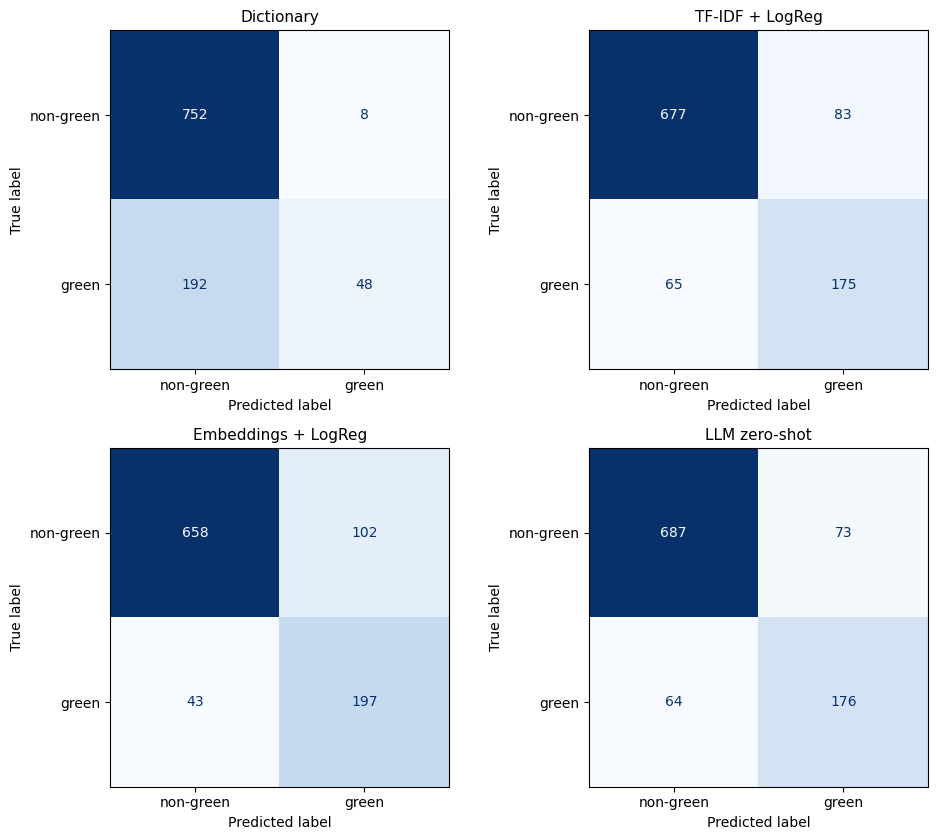

In [66]:
methods = [('Dictionary', pred_dict, val_df['green']),
           ('TF-IDF + LogReg', pred_tfidf, val_df['green']),
           ('Embeddings + LogReg', pred_emb, val_df['green']),
           ('LLM zero-shot', val_llm['llm_pred'].astype(int), val_llm['green'])]

fig, axes = plt.subplots(2, 2, figsize=(10, 8.5))

for ax, (name, preds, truth) in zip(axes.ravel(), methods):
    cm = confusion_matrix(truth, preds)
    ConfusionMatrixDisplay(cm, display_labels=['non-green', 'green']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=11)

plt.tight_layout()
plt.show()

Now, and only now, we pick a winner and evaluate it a single time on the test set.

In [ ]:
WINNER = 'embeddings'   # 'dictionary' | 'tfidf' | 'embeddings'

if WINNER == 'dictionary':
    pred_test = test_df['text'].apply(dictionary_predict).values
elif WINNER == 'tfidf':
    pred_test = clf_tfidf.predict(vectorizer.transform(test_df['text']))
else:
    E_test = embedder.encode(test_df['text'].tolist(), batch_size=64,
                             show_progress_bar=True)
    pred_test = clf_emb.predict(E_test)

report(test_df['green'], pred_test, f'{WINNER} — TEST SET')

## 8. Wrap-up

**What you did in this class**

1. Turned raw patent text into a structured variable
2. Split the data so that your final number means something
3. Started from a keyword dictionary, and saw exactly how it fails
4. Let the data pick the vocabulary with TF-IDF, and read the model's coefficients
5. Captured meaning rather than strings with pretrained embeddings, without training a neural network
6. Saw where an LLM fits, what it costs, and why it does not exempt you from validation
7. Compared everything on the same validation set, and touched test once

**Four things worth carrying away**

- Always compute the trivial benchmark, and always start from the simplest method. Sometimes it wins; when it loses, you learn what the complexity bought you.
- Your label is a measurement instrument with error, not the truth. Measurement error that correlates with your regressors is a confound.
- Predictive accuracy and suitability for causal inference are different criteria. The best classifier is not automatically the best variable.
- Choosing a model is a research design decision. Justify it and demonstrate it, the way you would an identification strategy.


*Reading.* Ash, E. and S. Hansen (2023), "Text Algorithms in Economics", **Annual Review of Economics** 15: 659-688. The survey to read before your first text-as-data paper (freely available at `sekhansen.github.io/pdf_files/are_2023.pdf`). Sections on validation and on measurement error in downstream regressions are the most directly useful for empirical work.

*Code.* The companion notebooks at `github.com/sekhansen/text_algorithms_econ` go well beyond today: preprocessing pipelines, LDA topic models, word2vec, BERT feature extraction, and fine-tuning.

*Beyond classification.* Topic models for research themes, `networkx` for citation and collaboration networks, embedding distance as a measure of novelty and recombination.

**Exercise to take home.** Take 200 documents from your own research corpus, label them by hand, and run Sections 3 to 7 on them.